---
# Computergestützte Datenauswertung
**Institut für Experimentelle Teilchenphysik (ETP)** <br>
**Institut für Theorie der Kondensierten Materie (TKM)** <br>
Prof. Dr. Ulrich Husemann (ETP) <br>
Dr. Thorsten Chwalek (ETP), Dr. Andreas Poenicke (TKM) <br>
[ILIAS-Seite zum Kurs](https://ilias.studium.kit.edu/ilias.php?baseClass=ilrepositorygui&ref_id=2627198) <br>
Sommersemester 2025 – Blatt 01 <br>
Abgabe: Montag, 5.05.2025 & Dienstag, 6.05.2025 

---

Auf dem ersten echten Übungsblatt setzen Sie sich mit den Bibliotheken *NumPy* und *Matplotlib* auseinander und werten ein Würfelspiel aus. 
Die [erste Aufgabe](#Aufgabe1) bietet die Möglichkeit, die sehr viel verwendete *Python*-Bibliothek *NumPy* kennenzulernen und den Einsatz von elementweisen Vektoren und die Erzeugung von Zufallszahlen zu üben.
In der [zweiten Aufgabe](#Aufgabe2) beschäftigen Sie sich mit der Visualisierung von "gemessenen" Daten und der Vergleich zu der entsprechenden Erwartung.
Die [letzte Aufgabe][#Aufgabe3) behandelt ein Zufallsexperimente mit Würfeln.


---
# Aufgabe 1: Datenauswertung: *NumPy* <a id="Aufgabe1"></a>
---
Vieles lässt sich bereits mit dem Standardbefehlssatz von *Python* erreichen.
Im Bereich der Datenauswertung hat sich jedoch die Bibliothek [*NumPy*](https://numpy.org/devdocs/user/index.html) zu einem Standard entwickelt, da diese nicht nur zusätzliche Funktionen bietet, sondern auch gerade bei größeren Datenmengen deutlich schneller arbeitet.
Funktionen - wie die Fakultät - müssen Sie in der Zukunft selten selbst implementieren, schauen Sie bei üblichen mathematischen Funktionen erst nach, ob diese nicht bereits in *NumPy* oder *SciPy* definiert wurden.

Einen weitere wichtige Anwendung von *NumPy* haben Sie bereits in der Vorlesung kennengelernt: Die Erzeugung von (Pseudo-) Zufallszahlen. 

**Arbeitsanweisung:**<br>
Ziel dieser Aufgabe ist es, Ihr eigenes kleines Zufallsexperiment zu schreiben.
Simulieren Sie hierzu den Wurf eines Würfels mit den Augenzahlen $\{1, \dots,6\}$ insgesamt 10 Mal.
Übeberlegen Sie sich, wie wahrscheinlich jeder Wert auftreten kann und welche Verteilung von Zufallszahlen Sie hierfür benötigen. 
Speichern Sie die Häufigkeit jeder Augenzahl in einem `numpy.array` und lassen Sie sich die Werte ausgeben. 
Wiederholen Sie Ihre Simulation mit 100 bzw. 1000 Würfen. 
Erhalten Sie das erwartete Ergebnis?

**Hinweise:**<br>
1. Die *NumPy*-Bibliothek (und viele weitere Bibliotheken) ist bereits auf dem *Jupyter*-Server installiert. Die übliche Weise, *NumPy* in Ihren *Python*-Skripten (und *Jupyter*-Notebooks) aufzurufen, ist wie folgt:
    ```python
    import numpy as np
    ```
    Anschließend können Sie auf jede Funktionalität mit `np` zugreifen, bspw.:
    ```python
    a = np.array([1, 2, 3])
    ```
2. Erzeugen Sie mit `numpy.random.default_rng()` einen Standard-Zufallszahlengenerator. Suchen Sie für die Erzeugung der Zufallszahlen eine passende Funktion in der Dokumentation von [`numpy.random.Generator`](https://numpy.org/doc/stable/reference/random/generator.html#simple-random-data) aus oder verwenden Sie die Ihnen aus der Vorlesung bekannten Beispielfunktionen.

In [5]:
# Importieren von numpy
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# Anzahl an Würfen
n = 10 # oder 100 oder 1000

# Implementation des Zufallsexperiments

#define used dice
dice_sides = 6
throws = 10000

#create random number generator
rng = np.random.default_rng()
dice_results = rng.integers(low=1, high=dice_sides+1, size=throws)

#collection that maps dice sides to absolut value with which they appeared while throwing the dice
my_dic = {i:j for i, j in zip(range(1, dice_sides+1), np.zeros((dice_sides,), int))}

#indicete the total amount for each dice value and store them in the collection
for k in range(1, dice_sides+1):
    amount_of_value = len([l for l in dice_results if l == k])
    my_dic[k] = amount_of_value

x = [k for k in my_dic.keys()]
y = [my_dic[k] for k in my_dic.keys()]

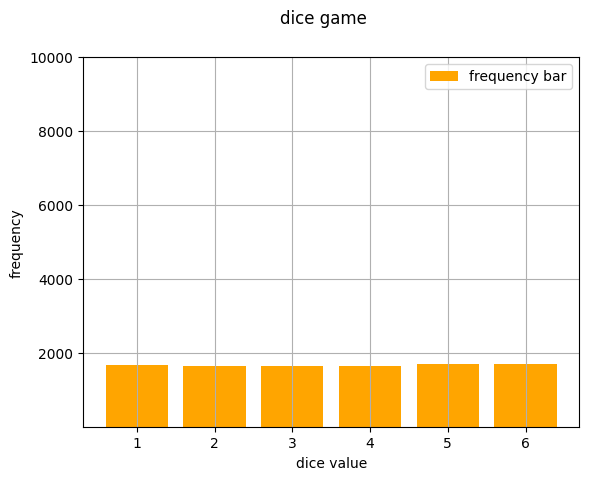

In [34]:
# Create a bar chart that illustrates the outcome of the dice game
figure, ax1 = plt.subplots(1, 1)
figure.suptitle("dice game")
ax1.bar(x, y, color='orange', label = 'frequency bar')
ax1.set_xlabel("dice value")
ax1.set_ylabel("frequency")
ax1.set_ylim(bottom=1, top=throws)
ax1.set_xticks([val for val in range(1, dice_sides+1)])
ax1.grid()
ax1.legend()
plt.show()


In [ ]:
# Aufzählen der Häufigkeit


---
# Aufgabe 2: Darstellungen von Daten: *Matplotlib* <a id="Aufgabe2"></a>
---
Ein wichtiger Schritt bei der Datenauswertung ist die Visualisierung der Daten. 
Durch die Bibliothek [*Matplotlib*](https://matplotlib.org/stable/tutorials/index) steht Ihnen hierzu ein mächtiges Werkzeug zur Verfügung, welches auch oft in Kombination mit *NumPy* verwendet wird.

**Arbeitsanweisung:**<br>
Simulieren Sie in den **folgenden Zellen** gemäß der zugehörigen Anleitung eine Datennahme von "Messwerten", die einer Parabel $f(x)=x^2$ folgen. 
Stellen Sie anschließend das Ergebnis geeignet dar. 
Die Darstellung soll die "Messwerte" inklusive deren Unsicherheiten sowie das vorausgesagte Modell enthalten.

**Anmerkung:**<br>
Ähnliche Problemstellungen, also der Vergleich von Daten mit einer Modellfunktion, treten in der Datenauswertung sehr häufig auf. 
Es lohnt sich daher, an Ihrem Code sehr sorgfältig zu arbeiten, damit Sie ihn oder Teile davon später weiter verwenden können. 
Sie erhalten hier Ihr eigenes, flexibles Grafikwerkzeug für den Vergleich von Daten mit Modellen, auf das Sie immer wieder zurückgreifen können.

Berechnen Sie zunächst die Parabel $f(x)=x^2$ im Wertebereich $x \in [0, 5]$ für 1000 $x$-Werte. 

**Hinweise:**<br>
1. Zur Erstellung der $x$-Werte können Sie die Funktion [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) verwenden. 
2. Beachten Sie, dass Exponenten in *Python* mit `**` angegeben werden (z.B. `2**3=8`)

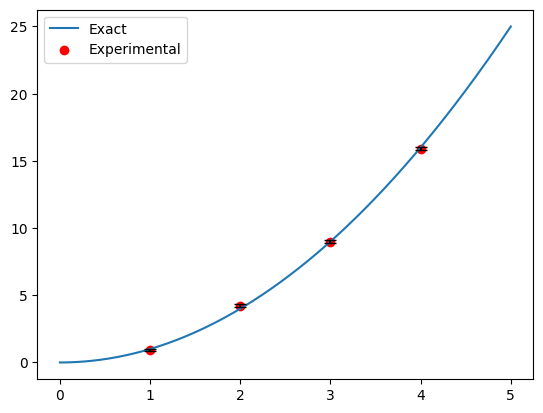

In [54]:
# Importieren der benötigten Module
import numpy as np
import matplotlib.pyplot as plt
"""Create a a data set that is coming from a fictive experiment which values are not exact.
To includ ethat the values are not exact adjust the exact output with a uncertanty. x + u = y
"""
"""#build the comparison function
exact_values = [j**2 for j in np.linspace(0, 5, 1000)]

#Creata a gaussian normal distribution that approximates the uncertainty
rng = np.random.default_rng()
dev_values = rng.normal(loc=0, scale=0.1, size=4) #loc: center of distribution, scale: standard deviation - spread or allowed with for failures

#create data set for the values for x element of {1, ..., 10}
x_exp = np.arange(1, 5, 1)
y_exp = x_exp ** 2 + dev_values

#draw the two lines in the same plot
fig, ax1 = plt.subplots(1, 1)
ax1.plot(np.linspace(0, 5, 1000), exact_values)

ax1.scatter(x_exp, y_exp, color="red")

#draw errorbarrs that show the uncertainty in which the values lie -> but what does decide the vertical widt for them?
ax1.errorbar(x_exp, y_exp, yerr=0.1, uplims=True, lolims=True)"""
fig, ax1 = plt.subplots(1, 1)

# Plot the theoretical curve
ax1.plot(np.linspace(0, 5, 1000), exact_values, label="Exact")

# Plot the experimental data
ax1.scatter(x_exp, y_exp, color="red", label="Experimental")

# Add the vertical error bars
# yerr=0.1 means the bar extends 0.1 units above and below the point
ax1.errorbar(x_exp, y_exp, yerr=0.1, fmt='none', ecolor='black', capsize=4)

ax1.legend()
plt.show()

In [ ]:
# Definition von y=x^2


Erzeugen Sie "Messwerte" für $x \in \{1, 2 ,3 ,4\}$, die jeweils dem Wert $f(x)$ mit einer normalverteilten (auch: gaußförmigen) Unsicherheit von $10 \%$ des wahren Werts entsprechen. 
Erzeugen Sie hierfür ein *NumPy*-Array mit vier Zufallszahlen aus einer Standard-Normalverteilung. 
Wenn Sie diese Werte mit der gewünschten Unsicherheit (also $0.1\cdot x^2$) multiplizieren, erhalten Sie die Zufallskomponente eines jeden Datenpunktes, die Sie zu den berechneten $y$-Werten addieren.

**Hinweise:**<br>
1. Suchen Sie erneut für die Erzeugung der Zufallszahlen eine passende Funktion in der Dokumentation von [`numpy.random.Generator`](https://numpy.org/doc/stable/reference/random/generator.html#distributions) aus.
2. Anmerkung: Für besonders kurzen (und übersichtlichen) Code nutzen Sie die elementweise Vektorisierung von *NumPy* aus. Z.B.: 
    ```python
    a = np.array([1, 2, 3])
    b = a + a # bzw. b = 2*a
    print(b) # Ausgabe: array([2, 4, 6])
    ```

In [ ]:
# Erstellen der Datenpunkte


Stellen Sie nun das Ergebnis in einem Plot dar. 
Zeigen Sie die erwartete Parabel als eine Linie und die erzeugten "Messwerte" als Kreise mit Fehlerbalken. 
Denken Sie ebenfalls an das Hinzufügen von Achsenbeschriftungen und einer Legende. 

**Hinweise:**<br>
1. Im Allgemeinen werden Sie einen Großteil der einfachen Darstellungen mithilfe von [`plt.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) erledigen können.
2. Fehlerbalken können am einfachsten mit [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) dargestellt werden.
3. Geben Sie den Darstellungsfunktionen (`plt.plot`, `plt.errorbar`,...) jeweils ein `label`-Parameter mit, welcher in der Legende dargestellt wird.
4. Machen Sie sich mit [`plt.xlabel`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlabel.html), [`plt.ylabel`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ylabel.html) und [`plt.legend`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html) vertraut.

In [ ]:
# Darstellung in einem Plot inkl. Achsenbeschriftung und Legende


---
# Aufgabe 3: Würfelspiel <a id="Aufgabe3"></a>
---
In dieser Aufgabe führen Sie Zufallsexperimente mit Würfeln aus.
Sie werfen jedes Mal $n$ Würfel gleichzeitig und betrachten die resultierende Augensumme.
Ziel dieser Aufgabe ist es, das Durchführen und grafische Darstellen von Zufallsexperimenten zu vertiefen.

Sie können folgende Funktion für die Simulation eines Würfelergebnisses mit drei Würfeln verwenden.
Sie erhalten beim Ausführen der `dice()` Funktion die drei gewürfelten Augenzahlen.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

def dice():
    # Wurf von 3 Würfeln
    return rng.integers(low=1, high=7, size=3)

**Arbeitsanweisung:**<br>
Zunächst spielen Sie mit 3 Würfeln.
Summieren Sie für jeden Wurf mit 3 Würfeln die Augensumme $S$ der Würfel.
Führen Sie 1000 solcher Spiele durch und stellen Sie die Häufigkeitsverteilung der Augensumme $S$ grafisch dar.

**Hinweis:**<br>
Verwenden Sie gerne die Funktion [`matplotlib.pyplot.hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) zur Darstellung der Häufigkeit der verschiedenen Augensummen.
Eine sehr einfach Verwendung der Funktion ist, `plt.hist(a, b)` in der `a` das Array ist, welches all die Aufgensummen enthält, und `b` das Binning vorgibt. 
Geben Sie beispielsweise eine Integerzahl für `b` ein, so werden `b` Bins zur Darstellung verwendet.
Überlegen Sie sich, wie viele Bins sie für alle möglichen Augensummen Ergebnisse mit 3 Würfeln benötigen würden.

*Anmerkung*: Sie können auch eine Liste oder ein `numpy.array` mit $n_\mathsf{bins}+1$ Einträgen als `b` übergeben. Diese werden als die Bingrenzen interpretiert.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Durchführen des Zufallsexperiments:
# 3 Würfel, 1000 Mal geworfen


In [ ]:
# Grafische Darstellung des Ergebnisses


Verallgemeinern Sie Ihren Code oder die oben angegebene Funktion so, dass Sie auch mit einer beliebigen Zahl von $n$ Würfeln gleichzeitig $N$ Spiele spielen können.
Berechnen Sie nun anstelle der Augensumme die mittlere Augensumme $\bar{s}=S/n$ und geben Sie für alle $N$ Spiele die mittlere Augensumme $\bar{s}$ in der neuen Funktion aus.
Stellen Sie anschließend die Häufigkeitsverteilung der mittleren Augenzahl für $n=10$, $n=50$ und $n=100$ für jeweils $N=1000$ Spiele dar.

In [ ]:
# Ggfls. neue Funktion zum Wüfeln definieren


In [ ]:
# Anzahl an Spielen
N = 1000

# Durchführung des Zufallexperiments und grafische Darstellung


Wiederholen Sie nun die Zufallsexperimente mit $n=5$ und $n=100$ Würfel für $N=10000$ Spiele. 
Bestimmen Sie für beide Durchläufe jeweils die Stichprobenstandardabweichung und das arithmetische Mittel und zeichnen Sie eine Normalverteilung mit den ausgerechneten Werten mit in das Histogramm.
Was beobachten Sie für die jeweilige Würfelanzahl?

**Hinweise:**<br>
1. eine Funktion, die die Normalverteilung implementiert, ist in der folgenden Zelle gegeben. Wenn Sie die Verteilung mit dem Histogramm zusammen darstellen wollen, müssen Sie entweder das Histogramm normieren (fügen Sie folgende Option hinzu zur Darstellung vom Histogramm: `plt.hist(..., density=True)`) oder die Darstellung der Normalverteilung.
2. Wiederholen Sie die Zufallsexperimente gerne einige Mal durch mehrfaches Ausführen der Zelle, um den Unterschied zu beobachten.

In [ ]:
# Funktion für die Normalverteilung
def Gaussian(x, mu=0., sigma=1.):
    return np.exp(-(x - mu)**2 / 2 / sigma**2) / np.sqrt(2*np.pi) / sigma

In [ ]:
# Anzahl an Spielen
N = 10000

# Durchführung des Zufallexperiments und grafische Darstellung
